<a href="https://colab.research.google.com/github/Cykim0320/undergrad_ml_assignments/blob/main/05_assignment_glm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?
2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.
3. True or false, and explain: Logistic regression is a linear model.
4. True or false, and explain: Logistic regression cannot be used for classification.
5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?
6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.
7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

Q1.1

Linear models are useful because they are simple and easy to interpret. However, they can return any value from negative infinity to positive infinity, which does not work when the outcome has constraints. For example, probabilities have to be between 0 and 1, but a plain linear model can easily predict something like 1.3 or -0.2, which cannot be interpreted as a probability. The solution is to use a latent variable model: I compute a linear score in the background ($L = b \cdot x$), and then pass it through an activation function to get a prediction that actually respects the constraints. This way, I keep the interpretability of linear models while fixing the output range problem.

Q1.2

Cross-entropy comes from maximum likelihood estimation. The idea is to measure how likely it is to observe the data given the model parameters. For binary outcomes, the likelihood is a product of predicted probabilities, and taking the negative log of this likelihood gives binary cross-entropy. What makes it a good loss function is that it strongly penalizes confident incorrect predictions. For example, if the model assigns a probability of 0.99 to an outcome that is actually 0, the loss becomes very large. It also has useful mathematical properties, it is convex for logistic regression, so gradient descent can reliably find a good solution.

Q1.3

This is partially true. The latent variable $L = b \cdot x$ is linear, but the final prediction $\hat{p} = \frac{e^L}{1+e^L}$ is nonlinear because of the sigmoid activation function. One important thing to note, the decision boundary in the feature space is still linear, which means logistic regression cannot separate classes with a curved boundary without feature engineering. So it is linear in the latent space, but nonlinear overall.

Q1.4

False. Logistic regression is actually one of the most common approaches for classification. It outputs a predicted probability, and then I apply a threshold (usually 0.5) to get a hard class label. If $\hat{p} \geq 0.5$ I predict class 1, otherwise class 0. It can also be extended to multiple classes with multinomial logistic regression.

Q1.5

Not exactly. In linear regression, yes $b_k$ directly tells you how much $\hat{y}$ changes per unit increase in $x_k$. But in logistic regression, it is more complicated because of the sigmoid. The safest interpretation is: a positive coefficient means the feature is associated with a higher probability of the outcome, and a negative coefficient means a lower probability. The exact effect on $\hat{p}$depends on where the observation lies on the sigmoid curve, so the coefficient alone does not give a clean "1 unit = this much change" relationship.

Q1.6

False. Even though logistic regression applies a nonlinear sigmoid activation, the decision boundary in the feature space is still linear. So if the true relationship between features and the outcome is nonlinear, like a curved boundary, logistic regression cannot capture it without feature engineering. I would still need things like polynomial terms, interaction terms, or other transformations to handle that.

Q1.7

False. The two models are designed for different situations. If I use a linear model for a binary outcome, I can get predictions like 1.3 or -0.2, which cannot be interpreted as probabilities. Logistic regression fixes this by keeping predictions between 0 and 1. But for continuous, unbounded outcomes, linear regression is still the appropriate choice. So it is not that one is always better, it depends on what kind of outcome I am modeling.

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


In [17]:
# Q2.1 - Load & clean data
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv('data.csv', sep=';')

cols = ['Debtor', 'Tuition fees up to date', 'Scholarship holder',
        'Age at enrollment', 'Curricular units 1st sem (approved)', 'Target']
df = df[cols].copy()

print("Missing values:\n", df.isnull().sum())
print("\nTarget distribution:\n", df['Target'].value_counts())

# Binary target: 1 = Dropout, 0 = Graduate or Enrolled
df['dropout'] = (df['Target'] == 'Dropout').astype(int)

Missing values:
 Debtor                                 0
Tuition fees up to date                0
Scholarship holder                     0
Age at enrollment                      0
Curricular units 1st sem (approved)    0
Target                                 0
dtype: int64

Target distribution:
 Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


In [18]:
# Q2.2 - Logistic regression on binary dropout
features_bin = ['Debtor', 'Tuition fees up to date', 'Scholarship holder',
                'Age at enrollment']

X_bin = df[features_bin].copy()
y_bin = df['dropout']

scaler = MinMaxScaler()
X_bin['Age at enrollment'] = scaler.fit_transform(X_bin[['Age at enrollment']])

log_reg = LogisticRegression(penalty=None, max_iter=5000)
log_reg.fit(X_bin, y_bin)

coef_df = pd.DataFrame({
    'Variable': features_bin,
    'Coefficient': log_reg.coef_[0]
})
print(coef_df)

                  Variable  Coefficient
0                   Debtor     0.527794
1  Tuition fees up to date    -2.605666
2       Scholarship holder    -1.241665
3        Age at enrollment     2.641454


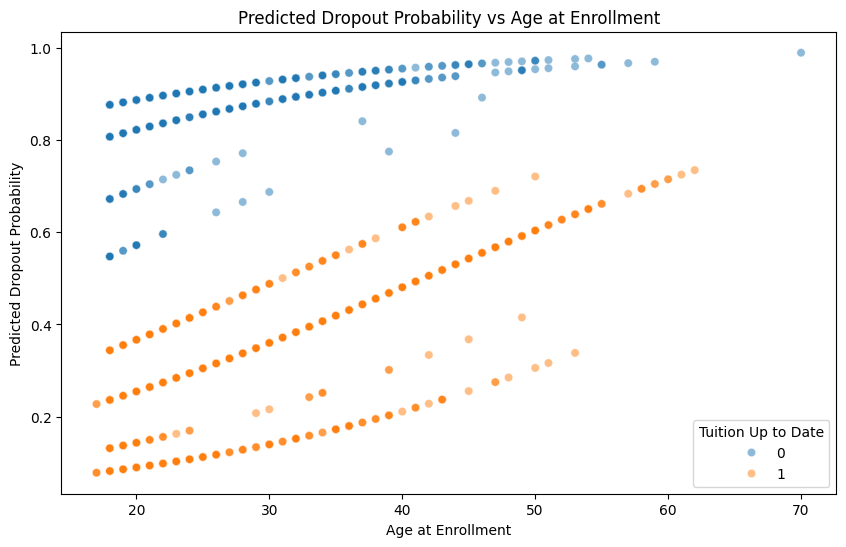

Avg dropout prob (tuition up to date): 0.247
Avg dropout prob (tuition NOT up to date): 0.866
Average difference (up-to-date minus not up-to-date): -0.618


In [19]:
# Q2.3 - predict_proba + scatter plot
proba = log_reg.predict_proba(X_bin)[:, 1]

plot_df = df[['Age at enrollment', 'Tuition fees up to date']].copy()
plot_df['Predicted Dropout Prob'] = proba

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=plot_df,
    x='Age at enrollment',
    y='Predicted Dropout Prob',
    hue='Tuition fees up to date',
    alpha=0.5
)
plt.title('Predicted Dropout Probability vs Age at Enrollment')
plt.xlabel('Age at Enrollment')
plt.ylabel('Predicted Dropout Probability')
plt.legend(title='Tuition Up to Date')
plt.show()

avg_up = plot_df.loc[plot_df['Tuition fees up to date'] == 1, 'Predicted Dropout Prob'].mean()
avg_not = plot_df.loc[plot_df['Tuition fees up to date'] == 0, 'Predicted Dropout Prob'].mean()

print(f"Avg dropout prob (tuition up to date): {avg_up:.3f}")
print(f"Avg dropout prob (tuition NOT up to date): {avg_not:.3f}")
print(f"Average difference (up-to-date minus not up-to-date): {avg_up - avg_not:.3f}")

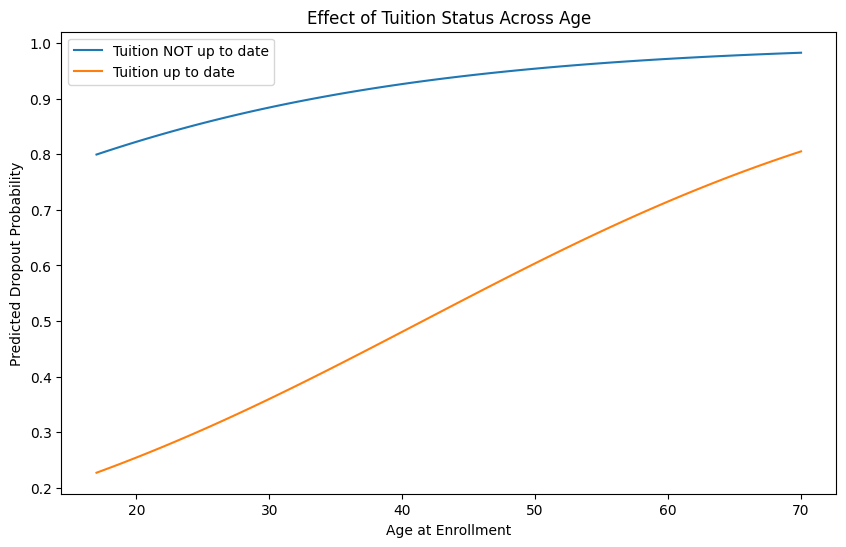

In [20]:
# Optional: tuition effect by age
age_grid = np.linspace(df['Age at enrollment'].min(), df['Age at enrollment'].max(), 100)

grid0 = pd.DataFrame({
    'Debtor': 0,
    'Tuition fees up to date': 0,
    'Scholarship holder': 0,
    'Age at enrollment': age_grid
})

grid1 = grid0.copy()
grid1['Tuition fees up to date'] = 1

grid0_scaled = grid0.copy()
grid1_scaled = grid1.copy()

grid0_scaled['Age at enrollment'] = scaler.transform(grid0[['Age at enrollment']])
grid1_scaled['Age at enrollment'] = scaler.transform(grid1[['Age at enrollment']])

p0 = log_reg.predict_proba(grid0_scaled)[:, 1]
p1 = log_reg.predict_proba(grid1_scaled)[:, 1]

plt.figure(figsize=(10, 6))
plt.plot(age_grid, p0, label='Tuition NOT up to date')
plt.plot(age_grid, p1, label='Tuition up to date')
plt.xlabel('Age at Enrollment')
plt.ylabel('Predicted Dropout Probability')
plt.title('Effect of Tuition Status Across Age')
plt.legend()
plt.show()

In [21]:
# Q2.4 - Confusion matrix & accuracy
y_pred = log_reg.predict(X_bin)

tab = pd.crosstab(
    pd.Series(y_bin.values, name='Actual'),
    pd.Series(y_pred, name='Predicted')
)
acc = np.trace(tab.values) / len(y_pred)

print(f"Confusion Matrix:\n{tab}")
print(f"\nAccuracy: {acc:.4f}")

Confusion Matrix:
Predicted     0    1
Actual              
0          2841  162
1           891  530

Accuracy: 0.7620


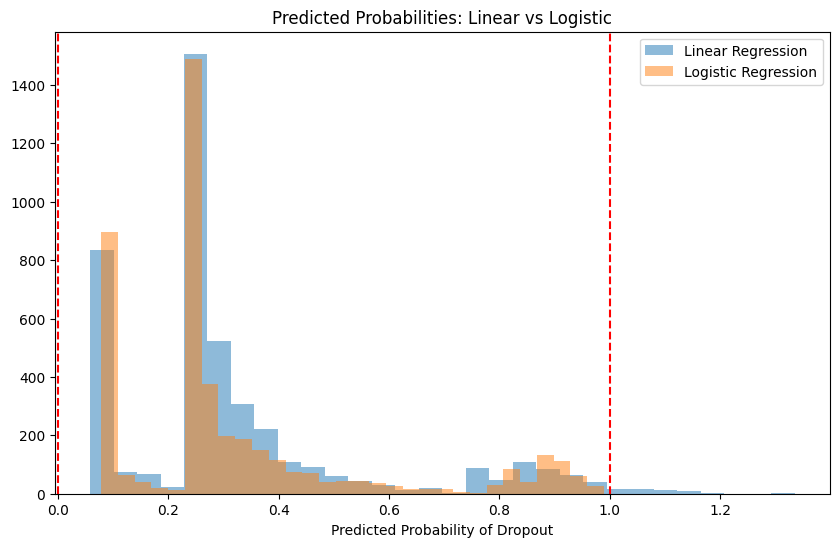

Linear regression min/max predictions:
0.05832035022573867 1.334953570675872


In [22]:
# Q2.5 - Linear model comparison
lin_reg = LinearRegression()
lin_reg.fit(X_bin, y_bin)
y_hat_lin = lin_reg.predict(X_bin)

plt.figure(figsize=(10, 6))
plt.hist(y_hat_lin, alpha=0.5, bins=30, label='Linear Regression')
plt.hist(proba, alpha=0.5, bins=30, label='Logistic Regression')
plt.axvline(x=0, color='red', linestyle='--')
plt.axvline(x=1, color='red', linestyle='--')
plt.xlabel('Predicted Probability of Dropout')
plt.title('Predicted Probabilities: Linear vs Logistic')
plt.legend()
plt.show()

print("Linear regression min/max predictions:")
print(y_hat_lin.min(), y_hat_lin.max())

In [23]:
# Q2.6 - Most at-risk students
risk_df = df[features_bin + ['Target', 'dropout']].copy()
risk_df['Predicted Dropout Prob'] = proba

risk_df = risk_df.sort_values('Predicted Dropout Prob', ascending=False)
print(risk_df.head(10))

      Debtor  Tuition fees up to date  Scholarship holder  Age at enrollment  \
689        1                        0                   0                 70   
2876       1                        0                   0                 54   
717        1                        0                   0                 53   
1887       1                        0                   0                 51   
3472       1                        0                   0                 50   
678        1                        0                   0                 50   
709        1                        0                   0                 50   
3526       1                        0                   0                 49   
3281       0                        0                   0                 59   
4260       1                        0                   0                 48   

       Target  dropout  Predicted Dropout Prob  
689   Dropout        1                0.989561  
2876  Dropout        

In [24]:
# Q2.7 - Multinomial logistic regression
features_multi = ['Debtor', 'Tuition fees up to date',
                  'Curricular units 1st sem (approved)']

X_multi = df[features_multi].copy()
y_multi = df['Target']

scaler2 = MinMaxScaler()
X_multi['Curricular units 1st sem (approved)'] = scaler2.fit_transform(
    X_multi[['Curricular units 1st sem (approved)']]
)

mnl = LogisticRegression(penalty=None, max_iter=5000)
mnl.fit(X_multi, y_multi)

y_multi_pred = mnl.predict(X_multi)
tab_multi = pd.crosstab(
    pd.Series(y_multi.values, name='Actual'),
    pd.Series(y_multi_pred, name='Predicted')
)
acc_multi = np.trace(tab_multi.values) / len(y_multi_pred)

print(f"Multinomial Confusion Matrix:\n{tab_multi}")
print(f"\nAccuracy: {acc_multi:.4f}")

proba_multi = pd.DataFrame(mnl.predict_proba(X_multi), columns=mnl.classes_)
print("\nSample predicted probabilities:")
print(proba_multi.head(10))

print("\nPredicted classes present in hard classification:")
print(pd.Series(y_multi_pred).value_counts())

print("\nAverage predicted probabilities by class:")
print(proba_multi.mean())

Multinomial Confusion Matrix:
Predicted  Dropout  Graduate
Actual                      
Dropout       1054       367
Enrolled       280       514
Graduate       146      2063

Accuracy: 0.3544

Sample predicted probabilities:
    Dropout  Enrolled  Graduate
0  0.679242  0.212155  0.108603
1  0.706543  0.145154  0.148303
2  0.953914  0.040760  0.005326
3  0.117473  0.176414  0.706113
4  0.183822  0.212487  0.603691
5  0.307760  0.325511  0.366730
6  0.071671  0.139830  0.788498
7  0.953914  0.040760  0.005326
8  0.117473  0.176414  0.706113
9  0.842953  0.121970  0.035076

Predicted classes present in hard classification:
Graduate    2944
Dropout     1480
Name: count, dtype: int64

Average predicted probabilities by class:
Dropout     0.321139
Enrolled    0.179536
Graduate    0.499326
dtype: float64


Q2.1

The data was loaded using a semicolon delimiter. After filtering to the relevant columns,
there were no missing values, so no rows were dropped. The target variable has three classes:
Graduate (2209), Dropout (1421), and Enrolled (794). For parts 2-5, I created a binary
target where Dropout = 1 and Graduate or Enrolled = 0.

Q2.2

Being a debtor (coefficient: 0.53) and older age at enrollment (coefficient: 2.64) are
associated with a higher dropout probability. Being up to date on tuition (coefficient: -2.61)
and being a scholarship holder (coefficient: -1.24) are associated with a lower dropout
probability. Yes, being up to date on tuition appears to strongly reduce dropout risk, it has the largest negative coefficient among all variables.

Q2.3

From the scatter plot, both groups show increasing dropout probability with age, but the gap between the two groups stays large across all ages. The second plot (tuition effect across age) makes this clearer, the blue line (tuition not up to date) starts already above 0.8 at age 18 and flattens near 1.0, while the orange line (tuition up to date) starts around 0.23 and increases more gradually. This means being up to date on tuition reduces dropout probability at all ages, and the gap remains large at older ages as the tuition-up-to-date group continues to rise while the other group is already near 1.0. On average, students who are up to date on tuition have a much lower predicted dropout probability than those who are not, with a difference of about 0.6.


Q2.4

The model achieved an accuracy of 76.2%. Looking at the confusion matrix, the model
correctly identifies most non-dropout students (2841 correct), but misses quite a few
actual dropouts (891 false negatives). This suggests the model tends to predict
"not dropout" more often, which makes sense given that non-dropouts are the majority class.

Q2.5

From the histogram, both models produce very similar overall distributions, which is
actually not surprising, for most observations, both models agree. However, the linear
model clearly produces predictions beyond 1.0 (visible past the right red dashed line),
which cannot be interpreted as probabilities. The logistic regression keeps all predictions
strictly between 0 and 1. This is the key practical advantage of logistic regression for
binary outcomes, it gives valid probability estimates, while the linear model can
produce out-of-range values that are meaningless in this context.

Q2.6

Based on the model, the most at-risk students are older, have outstanding debt, are not
up to date on tuition, and do not hold a scholarship. Looking at the top 10 highest-risk
predictions, they are all students with debt, no tuition payment, and older ages, with
predicted dropout probabilities above 0.97. Possible interventions could include targeted
financial aid or flexible payment plans for students with debt, early warning systems that
flag students who fall behind on tuition, and additional support programs for older or
non-traditional students who may face more external pressures.

Q2.7

The multinomial model achieved an accuracy of only 35.4%, which is much lower than the
binary model. Looking at the confusion matrix, the hard classification only predicts two
classes, Dropout and Graduate, and never predicts Enrolled at all. This is confirmed
by the class counts: Graduate (2944) and Dropout (1480), with zero predictions for Enrolled.
This is likely because the features used do not provide enough signal to distinguish
Enrolled students from the other two groups.

However, the predicted probabilities do assign non-zero values to all three classes for
every observation, the average predicted probability for Enrolled is 0.18, so the model
does consider it as a possibility. The hard classification collapses it entirely because
Enrolled never has the highest probability among the three. This highlights a key
limitation of hard classification: it can completely miss minority classes even when
the underlying probabilities suggest meaningful uncertainty across all classes.

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

In [25]:
# Q3.1 - Load & clean data
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv('cirrhosis.csv')

cols = ['Bilirubin', 'Edema', 'Drug', 'Stage', 'Status']
df = df[cols]

print("Missing values before:\n", df.isnull().sum())
# Drug has 106 missing values and Stage has 6.
# I dropped all rows with missing values, leaving 312 observations.
df = df.dropna()
print("\nShape after dropna:", df.shape)

# Binary target: 1 = alive (C or CL), 0 = dead (D)
df['alive'] = (df['Status'] != 'D').astype(int)
print("\nAlive distribution:\n", df['alive'].value_counts())

# One-hot encode Edema and Drug
df_enc = pd.get_dummies(df, columns=['Edema', 'Drug'], drop_first=False)

Missing values before:
 Bilirubin      0
Edema          0
Drug         106
Stage          6
Status         0
dtype: int64

Shape after dropna: (312, 5)

Alive distribution:
 alive
1    187
0    125
Name: count, dtype: int64


In [26]:
# Q3.2 - Logistic regression on survival
features_surv = ['Edema_S', 'Edema_Y', 'Drug_D-penicillamine', 'Bilirubin']

X_surv = df_enc[features_surv].copy()
y_surv = df_enc['alive']

scaler = MinMaxScaler()
X_surv['Bilirubin'] = scaler.fit_transform(X_surv[['Bilirubin']])

log_surv = LogisticRegression(penalty=None, max_iter=5000)
log_surv.fit(X_surv, y_surv)

coef_surv = pd.DataFrame({
    'Variable': features_surv,
    'Coefficient': log_surv.coef_[0]
})
print(coef_surv)

               Variable  Coefficient
0               Edema_S    -0.578356
1               Edema_Y    -2.862466
2  Drug_D-penicillamine    -0.252087
3             Bilirubin    -9.704468


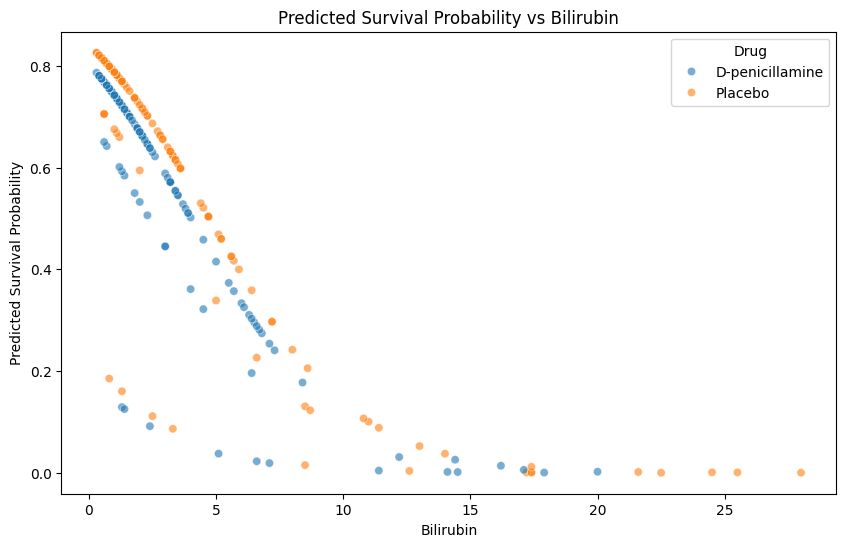

Avg survival prob (drug):    0.589
Avg survival prob (placebo): 0.610
Average difference: -0.022


In [27]:
# Q3.3 - predict_proba + scatter plot
proba_surv = log_surv.predict_proba(X_surv)[:, 1]

plot_surv = df[['Bilirubin', 'Drug']].copy()
plot_surv['Predicted Survival Prob'] = proba_surv

plt.figure(figsize=(10, 6))
sns.scatterplot(data=plot_surv,
                x='Bilirubin',
                y='Predicted Survival Prob',
                hue='Drug',
                alpha=0.6)
plt.title('Predicted Survival Probability vs Bilirubin')
plt.xlabel('Bilirubin')
plt.ylabel('Predicted Survival Probability')
plt.show()

avg_drug    = plot_surv[plot_surv['Drug'] == 'D-penicillamine']['Predicted Survival Prob'].mean()
avg_placebo = plot_surv[plot_surv['Drug'] == 'Placebo']['Predicted Survival Prob'].mean()
print(f"Avg survival prob (drug):    {avg_drug:.3f}")
print(f"Avg survival prob (placebo): {avg_placebo:.3f}")
print(f"Average difference: {avg_drug - avg_placebo:.3f}")

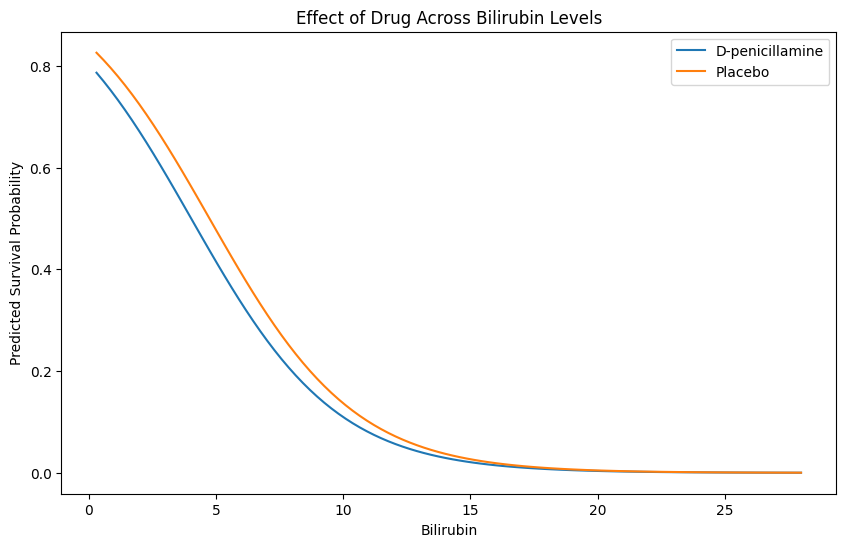

In [28]:
# Optional: drug effect by bilirubin
bili_grid = np.linspace(df['Bilirubin'].min(), df['Bilirubin'].max(), 100)

grid_drug = pd.DataFrame({
    'Edema_S': 0,
    'Edema_Y': 0,
    'Drug_D-penicillamine': 1,
    'Bilirubin': bili_grid
})
grid_placebo = grid_drug.copy()
grid_placebo['Drug_D-penicillamine'] = 0

grid_drug_scaled = grid_drug.copy()
grid_placebo_scaled = grid_placebo.copy()
grid_drug_scaled['Bilirubin'] = scaler.transform(grid_drug[['Bilirubin']])
grid_placebo_scaled['Bilirubin'] = scaler.transform(grid_placebo[['Bilirubin']])

p_drug = log_surv.predict_proba(grid_drug_scaled)[:, 1]
p_placebo = log_surv.predict_proba(grid_placebo_scaled)[:, 1]

plt.figure(figsize=(10, 6))
plt.plot(bili_grid, p_drug, label='D-penicillamine')
plt.plot(bili_grid, p_placebo, label='Placebo')
plt.xlabel('Bilirubin')
plt.ylabel('Predicted Survival Probability')
plt.title('Effect of Drug Across Bilirubin Levels')
plt.legend()
plt.show()

In [29]:
# Q3.4 - Confusion matrix & accuracy
y_pred_surv = log_surv.predict(X_surv)

tab_surv = pd.crosstab(pd.Series(y_surv.values, name='Actual'),
                       pd.Series(y_pred_surv, name='Predicted'))
acc_surv = np.trace(tab_surv.values) / len(y_pred_surv)
print(f"Confusion Matrix:\n{tab_surv}")
print(f"\nAccuracy: {acc_surv:.4f}")

Confusion Matrix:
Predicted   0    1
Actual            
0          57   68
1          14  173

Accuracy: 0.7372


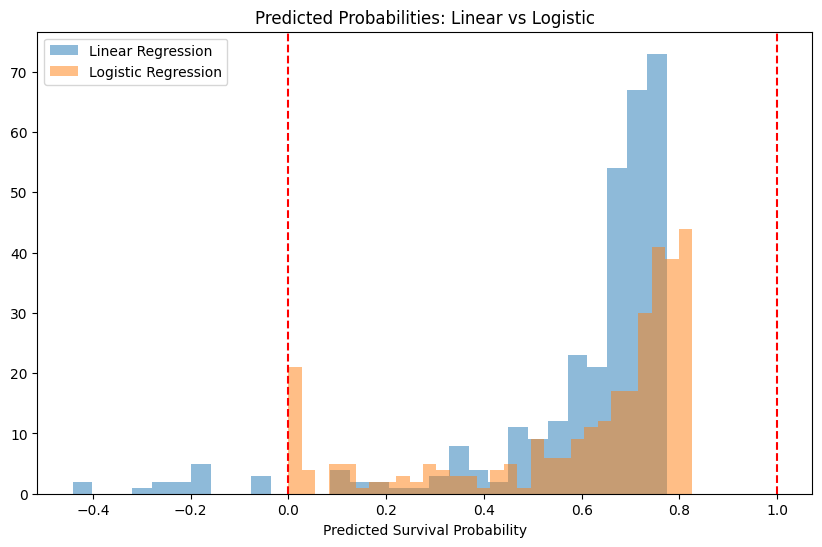

Linear regression min/max predictions:
Min: -0.442, Max: 0.774


In [30]:
# Q3.5 - Linear model comparison
lin_surv = LinearRegression()
lin_surv.fit(X_surv, y_surv)
y_hat_surv = lin_surv.predict(X_surv)

plt.figure(figsize=(10, 6))
plt.hist(y_hat_surv, alpha=0.5, bins=30, label='Linear Regression')
plt.hist(proba_surv, alpha=0.5, bins=30, label='Logistic Regression')
plt.axvline(x=0, color='red', linestyle='--')
plt.axvline(x=1, color='red', linestyle='--')
plt.xlabel('Predicted Survival Probability')
plt.title('Predicted Probabilities: Linear vs Logistic')
plt.legend()
plt.show()

print("Linear regression min/max predictions:")
print(f"Min: {y_hat_surv.min():.3f}, Max: {y_hat_surv.max():.3f}")

In [31]:
# Q3.6 - Multinomial logistic regression on Stage
features_stage = ['Edema_S', 'Edema_Y', 'Bilirubin']

X_stage = df_enc[features_stage].copy()
X_stage['Bilirubin'] = scaler.fit_transform(X_stage[['Bilirubin']])
y_stage = df_enc['Stage'].astype(int)

mnl_stage = LogisticRegression(penalty=None, max_iter=5000)
mnl_stage.fit(X_stage, y_stage)

y_stage_pred = mnl_stage.predict(X_stage)
tab_stage = pd.crosstab(pd.Series(y_stage.values, name='Actual'),
                        pd.Series(y_stage_pred, name='Predicted'))
acc_stage = np.trace(tab_stage.values) / len(y_stage_pred)
print(f"Stage Confusion Matrix:\n{tab_stage}")
print(f"\nAccuracy: {acc_stage:.4f}")

proba_stage = pd.DataFrame(mnl_stage.predict_proba(X_stage), columns=mnl_stage.classes_)
print("\nSample predicted probabilities:")
print(proba_stage.head(10))
print("\nPredicted classes present:")
print(pd.Series(y_stage_pred).value_counts())

Stage Confusion Matrix:
Predicted    3   4
Actual            
1           16   0
2           61   6
3          102  18
4           74  35

Accuracy: 0.0705

Sample predicted probabilities:
              1         2         3         4
0  3.819657e-08  0.022850  0.123768  0.853382
1  7.619898e-02  0.252808  0.397224  0.273770
2  6.490232e-06  0.175914  0.404287  0.419793
3  5.086697e-06  0.170391  0.403282  0.426322
4  2.040266e-02  0.228748  0.425645  0.325204
5  8.977320e-02  0.254103  0.390548  0.265575
6  8.050185e-02  0.253311  0.395099  0.271088
7  1.172314e-01  0.254650  0.377262  0.250857
8  2.294633e-02  0.231419  0.424329  0.321306
9  1.286208e-07  0.028139  0.132545  0.839316

Predicted classes present:
3    253
4     59
Name: count, dtype: int64


Q3.1

The data was loaded and filtered to the relevant columns. Drug had 106 missing values and Stage had 6 missing values. I dropped all rows with missing values, which left 312 observations. I created a binary survival variable where C and CL (alive) = 1 and D (dead) = 0. Edema and Drug were one-hot encoded for use in the model.

Q3.2

Higher bilirubin has a strong negative coefficient (-9.70), which means higher bilirubin is linked to a lower survival probability. Both edema categories are also negative, Edema S (-0.58) and Edema Y (-2.86), so having edema is associated with lower survival, and severe edema has a much stronger effect.

The drug (D-penicillamine) has a small negative coefficient (-0.25), which suggests it does not really improve survival in this model.

Q3.3

From the scatter plot and the drug effect plot, survival probability drops quickly as bilirubin increases for both groups. The placebo group has a slightly higher predicted survival probability than the drug group across all bilirubin levels, and this difference is more noticeable at lower bilirubin values (around 0 to 10).

At higher bilirubin levels, both groups drop close to zero and become very similar. On average, patients taking the drug have a predicted survival probability of 0.589, compared to 0.610 for the placebo group, a difference of about -0.02. This suggests the drug does not improve survival, and the difference between the two groups is very small.

Q3.4

The model achieved an accuracy of 73.7%. From the confusion matrix, the model is better at predicting alive patients (173 correct) than dead patients (57 correct). There are also 68 false positives, meaning some patients are predicted to survive when they actually do not.

Q3.5

From the histogram, the linear model gives predictions as low as -0.44, which can be seen to the left of the zero line. The logistic model keeps all predictions between 0 and 1.

Both models give similar overall patterns, with predictions concentrated in the higher range, particularly around 0.7–0.8 for the logistic model, which reflects the fact that more patients in this dataset are alive than dead. However, the linear model gives values outside the valid range, so it is not suitable for probabilities. The logistic model gives valid and easier-to-interpret predictions.

Q3.6

The model achieved a very low accuracy of 7.1%. The confusion matrix shows that it only predicts Stage 3 and Stage 4, and completely misses Stage 1 and Stage 2.

This likely happens because Stage 3 and 4 are more common, and the features used (Edema and Bilirubin) are not enough to clearly separate all four stages.

However, the predicted probabilities still give non-zero values for all stages. So even though the final prediction only shows two stages, the model is still considering all four in the background. This shows a limitation of hard classification — it only picks the most likely class, so smaller groups can disappear even if the model still assigns them some probability.

**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio?

Q4.

The coefficients in a logistic regression are the values $b_k$ in the latent variable
$L = b \cdot x = b_0 + \sum_{k=1}^K b_k x_k$. The safest interpretation is: a positive
coefficient means the feature is associated with a higher probability of the outcome,
and a negative coefficient means a lower probability. Beyond that, the exact effect
on the predicted probability depends on where the observation lies on the sigmoid curve,
so the coefficients are not as directly interpretable as in linear regression.

Q4.1

For the linear model $\hat{y} = b_0 + \sum_{k=1}^K b_k x_k$, the derivative with
respect to the $k$-th feature is:

$$\frac{\partial \hat{y}}{\partial x_k} = b_k$$

So for a 1-unit change in $x_k$, the prediction changes by exactly $b_k$. This is
constant — it does not depend on the current value of $x$.

Q4.2

For the logistic model $\hat{p} = \frac{e^{b \cdot x}}{1 + e^{b \cdot x}}$, I use
the chain rule $D_x f(g(x)) = f'(g(x))g'(x)$ with $L = b \cdot x$:

$$\frac{\partial \hat{p}}{\partial x_k} = \frac{\partial \hat{p}}{\partial L} \cdot \frac{\partial L}{\partial x_k} = \hat{p}(1 - \hat{p}) \cdot b_k$$

Unlike the linear case, this derivative is not constant — it changes as $x$ changes,
because $\hat{p}$ itself depends on $x$. The effect of $b_k$ on the prediction is
scaled by $\hat{p}(1 - \hat{p})$, which is maximized when $\hat{p} = 0.5$, giving
a value of $0.25$. So when $\hat{p} \approx 0.5$, the effect of a 1-unit change in
$x_k$ on the prediction is approximately $\frac{b_k}{4}$, which means $b_k \times 4$
is roughly a good estimate of the effect at that point. As $\hat{p}$ moves toward
0 or 1, the effect shrinks and the coefficient becomes a worse approximation.

Q4.3

Starting from the prediction, I can transform it as follows:

$$\hat{p} = \frac{e^{b \cdot x}}{1 + e^{b \cdot x}}$$

$$\hat{p}(1 + e^{b \cdot x}) = e^{b \cdot x}$$

$$\hat{p} = (1 - \hat{p})e^{b \cdot x}$$

$$\log\left(\frac{\hat{p}}{1 - \hat{p}}\right) = b \cdot x$$

The left-hand side is the log odds ratio, and the right-hand side is the linear
latent variable. Since this relationship is linear, a 1-unit change in $x_k$
increases the log odds ratio by exactly $b_k$, regardless of the current value
of $x$. This is the cleanest interpretation of the coefficients in logistic
regression, they represent the change in log odds, not the change in probability.